In [ ]:
Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Step 2: Load the Dataset

In [7]:
df = pd.read_csv("credit_card_fraud_10k.csv")

In [ ]:
#Step 3: Initial Data Inspection

In [9]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [13]:
df.shape

(10000, 10)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [17]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [19]:

#Step 4: Drop Irrelevant Columns

In [21]:
df.drop(columns=['transaction_id'], inplace=True)

In [23]:
#Step 5: Check Class Imbalance (Very Important for Fraud)

In [25]:
df['is_fraud'].value_counts()


is_fraud
0    9849
1     151
Name: count, dtype: int64

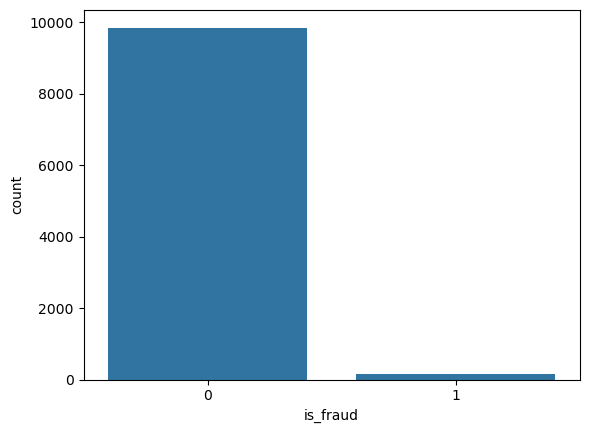

In [27]:
sns.countplot(x='is_fraud', data=df)
plt.show()

In [29]:
#Step 6: Separate Categorical & Numerical Columns

In [31]:
categorical_cols = ['merchant_category']
numerical_cols = df.drop(columns=['is_fraud', 'merchant_category']).columns

In [33]:
#Step 7: Encode Categorical Variable

In [35]:
df = pd.get_dummies(df, columns=['merchant_category'], drop_first=True)

In [37]:
#Step 8: Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [45]:
#Step 9: Split Features & Target

In [47]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [49]:
#Step 10: Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [55]:
#Step 11 : Handle Class Imbalance

In [57]:
from imblearn.over_sampling import SMOTE

In [59]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)



In [61]:
#Train Logistic Regression Model

In [63]:
from sklearn.linear_model import LogisticRegression


In [65]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [67]:
#Make Predictions

In [69]:

#Class Predictions

In [71]:
y_pred = log_model.predict(X_test)

In [73]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [75]:
#Probability Predictions 



In [77]:
y_prob = log_model.predict_proba(X_test)[:, 1]


In [79]:
y_prob

array([1.34072469e-03, 5.60950538e-04, 1.89264741e-06, ...,
       2.41383149e-04, 1.03048799e-04, 6.85144708e-04])

In [81]:
#Evaluation Metrics

In [83]:
#Confusion Matrix

In [85]:
from sklearn.metrics import confusion_matrix

In [87]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1886,   84],
       [   1,   29]], dtype=int64)

In [89]:
#Classification Report

In [91]:
from sklearn.metrics import classification_report

In [93]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      0.97      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.96      0.69      2000
weighted avg       0.99      0.96      0.97      2000



In [95]:
#ROC–AUC Score (Mandatory)

In [97]:
from sklearn.metrics import roc_auc_score

In [99]:
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

0.9931641285956008

In [101]:
#ROC Curve Plot

In [103]:
from sklearn.metrics import roc_curve

In [105]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

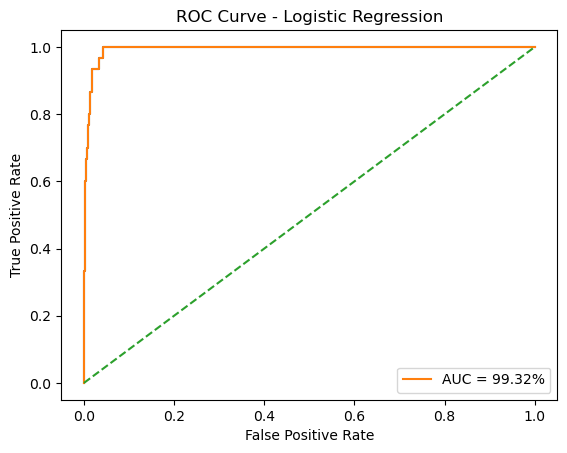

In [113]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc*100:.2f}%")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

In [115]:
#Precision–Recall Curve (Very Useful for Imbalanced Data)

In [117]:
from sklearn.metrics import precision_recall_curve

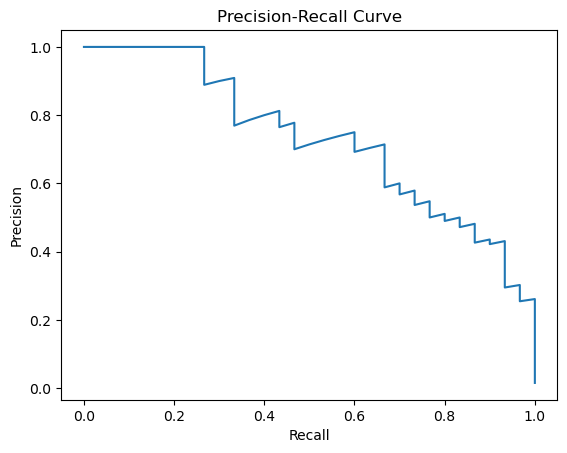

In [119]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [121]:
#Adjust Threshold (Advanced but IMPORTANT)


In [125]:
#Default threshold = 0.5 In fraud detection, we often lower it.

In [127]:
custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

In [129]:
#Re-evaluate:

In [131]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1970
           1       0.21      1.00      0.34        30

    accuracy                           0.94      2000
   macro avg       0.60      0.97      0.66      2000
weighted avg       0.99      0.94      0.96      2000

